# Viscoelasticity: Notebook 3
## 3. Laplace Transforms and Oscillatory Loading
- 7/31/2026 - Eugene Joseph M. Ragasa (MTSCO02/AY20252026T3)

The time-domain constitutive equation is a differential operator relating stress and strain histories. The Laplace transform converts this differential relation into an algebraic transfer function. Evaluating that transfer function on the imaginary axis gives the oscillatory response.

## Learning outcomes

- transform a linear constitutive equation into the Laplace domain;
- derive the complex modulus of a standard linear solid;
- interpret storage modulus, loss modulus, and phase lag;
- fit frequency-domain data using a shared set of material parameters.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

plt.rcParams.update({"figure.figsize": (7.0, 4.4), "axes.grid": True})


## 3.1 Constitutive differential operator

Write the standard-linear-solid constitutive equation as

$$
\sigma+\tau\dot\sigma
=E_\infty\epsilon+\tau E_0\dot\epsilon,
$$

where $E_0>E_\infty>0$ and $\tau>0$. With $D=\mathrm d/\mathrm dt$,

$$
(1+\tau D)\sigma=(E_\infty+\tau E_0D)\epsilon.
$$

The operators on the two sides specify the model. Stress, strain, and their initial conditions specify its state and response.

For zero initial conditions, $\mathcal L\{\dot f\}=s\widetilde f(s)$. Therefore,

$$
(1+s\tau)\widetilde\sigma(s)
=(E_\infty+s\tau E_0)\widetilde\epsilon(s).
$$

The stress-to-strain transfer function is

$$
\boxed{
\mathcal E(s)=\frac{\widetilde\sigma(s)}{\widetilde\epsilon(s)}
=\frac{E_\infty+s\tau E_0}{1+s\tau}
}.
$$


## 3.2 Recover the step-strain response

For $\epsilon(t)=\epsilon_0H(t)$, $\widetilde\epsilon(s)=\epsilon_0/s$. Partial-fraction inversion gives

$$
\sigma(t)=\epsilon_0
\left[E_\infty+(E_0-E_\infty)e^{-t/\tau}\right].
$$

Thus the pole at $s=-1/\tau$ produces the exponential relaxation mode. This is the same relaxation modulus derived directly in Notebook 2.

The transform does not introduce a new material model; it provides a different representation of the same constitutive operator.


## 3.3 Complex modulus

For steady harmonic loading, set $s=i\omega$:

$$
E^*(\omega)=\mathcal E(i\omega)
=\frac{E_\infty+i\omega\tau E_0}{1+i\omega\tau}
=E'(\omega)+iE''(\omega).
$$

Separating real and imaginary parts gives

$$
E'(\omega)=E_\infty
+(E_0-E_\infty)\frac{(\omega\tau)^2}{1+(\omega\tau)^2},
$$

$$
E''(\omega)=(E_0-E_\infty)
\frac{\omega\tau}{1+(\omega\tau)^2}.
$$

$E'$ measures in-phase elastic storage, while $E''$ measures the out-of-phase dissipative response. The phase angle satisfies $\tan\delta=E''/E'$.


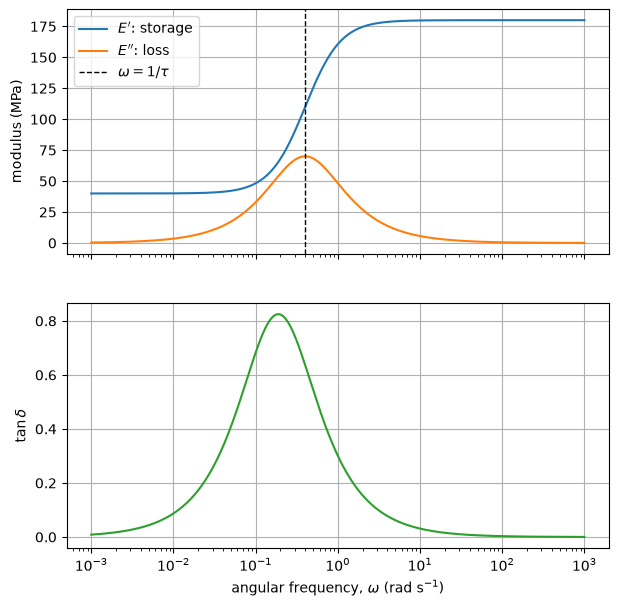

In [3]:
def complex_modulus_sls(omega, Einf, E0, tau):
    x = np.asarray(omega, dtype=float) * tau
    return (Einf + 1j * x * E0) / (1.0 + 1j * x)

Einf, E0, tau = 40.0, 180.0, 2.5
omega = np.geomspace(1e-3, 1e3, 800)
E_star = complex_modulus_sls(omega, Einf, E0, tau)
E_storage = E_star.real
E_loss = E_star.imag

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
ax0.semilogx(omega, E_storage, label="$E'$: storage")
ax0.semilogx(omega, E_loss, label="$E''$: loss")
ax0.axvline(1.0 / tau, color="black", linestyle="--", linewidth=1,
            label=r"$\omega=1/\tau$")
ax0.set_ylabel("modulus (MPa)")
ax0.legend()

ax1.semilogx(omega, E_loss / E_storage, color="C2")
ax1.set(xlabel=r"angular frequency, $\omega$ (rad s$^{-1}$)",
        ylabel=r"$\tan\delta$")
plt.show()


The low- and high-frequency limits are

$$
\lim_{\omega\to0}E'(\omega)=E_\infty,
\qquad
\lim_{\omega\to\infty}E'(\omega)=E_0.
$$

The loss modulus reaches its maximum at $\omega\tau=1$. Hence a frequency sweep locates the characteristic relaxation time through $\tau=1/\omega_{\mathrm{peak}}$.


## 3.4 Stress response and hysteresis

For an imposed strain $\epsilon(t)=\epsilon_a\sin\omega t$, the steady stress is

$$
\sigma(t)=\epsilon_a
\left[E'\sin\omega t+E''\cos\omega t\right].
$$

The stress leads the strain by $\delta$. A parametric plot of $\sigma$ against $\epsilon$ forms a hysteresis loop. The dissipated energy density per cycle is the loop area,

$$
W_{\mathrm{diss}}=\pi E''\epsilon_a^2.
$$


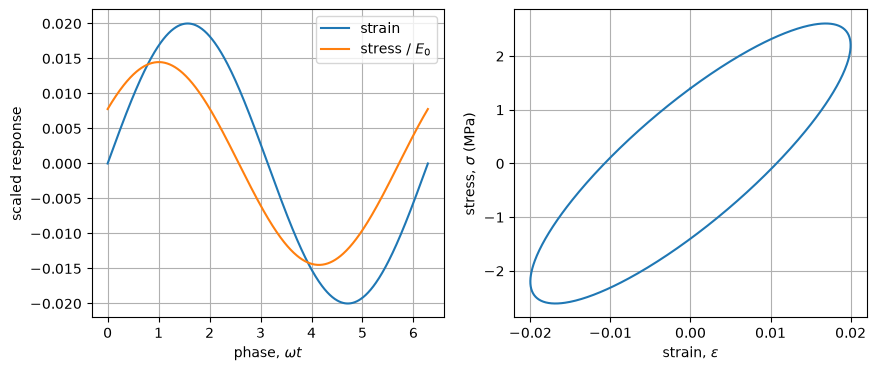

Dissipated energy density per cycle = 0.0880 MPa
Because 1 MPa = 1 MJ m^-3, this numerical value is also in MJ m^-3.


In [4]:
omega_drive = 1.0 / tau
strain_amplitude = 0.02
phase = np.linspace(0.0, 2.0 * np.pi, 500)
E_drive = complex_modulus_sls(omega_drive, Einf, E0, tau)
strain = strain_amplitude * np.sin(phase)
stress = strain_amplitude * (
    E_drive.real * np.sin(phase) + E_drive.imag * np.cos(phase)
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))
ax0.plot(phase, strain, label="strain")
ax0.plot(phase, stress / E0, label="stress / $E_0$")
ax0.set(xlabel=r"phase, $\omega t$", ylabel="scaled response")
ax0.legend()

ax1.plot(strain, stress)
ax1.set(xlabel=r"strain, $\epsilon$", ylabel=r"stress, $\sigma$ (MPa)")
plt.show()

W_diss = np.pi * E_drive.imag * strain_amplitude**2
print(f"Dissipated energy density per cycle = {W_diss:.4f} MPa")
print("Because 1 MPa = 1 MJ m^-3, this numerical value is also in MJ m^-3.")


## 3.5 Jointly fit storage and loss data

A physically consistent fit must use the same $(E_\infty,E_0,\tau)$ in both $E'$ and $E''$. Fitting the two curves independently would discard the constitutive constraint connecting them.


In [5]:
rng = np.random.default_rng(31)
omega_data = np.geomspace(0.01, 30.0, 45)
true = {"Einf": 45.0, "E0": 210.0, "tau": 1.8}
E_true = complex_modulus_sls(omega_data, **true)
noise_scale = 1.5  # MPa
Ep_measured = E_true.real + rng.normal(0.0, noise_scale, omega_data.size)
Epp_measured = E_true.imag + rng.normal(0.0, noise_scale, omega_data.size)

oscillatory_data = pd.DataFrame({
    "omega_rad_s": omega_data,
    "storage_modulus_MPa": Ep_measured,
    "loss_modulus_MPa": Epp_measured,
})
oscillatory_data.head()


,omega_rad_s,storage_modulus_MPa,loss_modulus_MPa
0,0.010000,44.460491,1.208721
1,0.011996,45.472764,1.671987
2,0.014390,46.021314,3.196004
3,0.017261,43.700894,6.383681
4,0.020706,46.380388,7.185770


In [6]:
def unpack(log_parameters):
    return np.exp(log_parameters)

def joint_residual(log_parameters):
    Einf_fit, E0_fit, tau_fit = unpack(log_parameters)
    prediction = complex_modulus_sls(omega_data, Einf_fit, E0_fit, tau_fit)
    return np.concatenate((
        (prediction.real - Ep_measured) / noise_scale,
        (prediction.imag - Epp_measured) / noise_scale,
    ))

result = least_squares(joint_residual, np.log([35.0, 180.0, 1.0]))
Einf_fit, E0_fit, tau_fit = unpack(result.x)

fit_table = pd.DataFrame({
    "parameter": ["Einf (MPa)", "E0 (MPa)", "tau (s)"],
    "true_value": list(true.values()),
    "fitted_value": [Einf_fit, E0_fit, tau_fit],
})
fit_table


,parameter,true_value,fitted_value
0,Einf (MPa),45.0,45.264774
1,E0 (MPa),210.0,210.046176
2,tau (s),1.8,1.777012


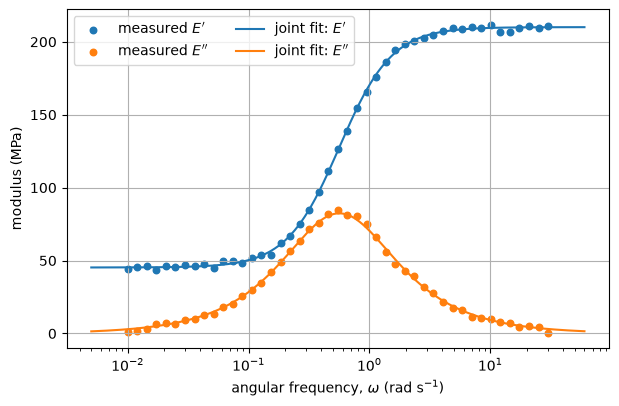

In [7]:
omega_plot = np.geomspace(0.005, 60.0, 600)
E_fit = complex_modulus_sls(omega_plot, Einf_fit, E0_fit, tau_fit)

fig, ax = plt.subplots()
ax.scatter(omega_data, Ep_measured, s=22, label="measured $E'$")
ax.scatter(omega_data, Epp_measured, s=22, label="measured $E''$")
ax.plot(omega_plot, E_fit.real, label="joint fit: $E'$")
ax.plot(omega_plot, E_fit.imag, label="joint fit: $E''$")
ax.set_xscale("log")
ax.set(xlabel=r"angular frequency, $\omega$ (rad s$^{-1}$)",
       ylabel="modulus (MPa)")
ax.legend(ncol=2)
plt.show()


## Exercises

1. Verify the formulas for $E'$ and $E''$ by multiplying numerator and denominator of $E^*$ by $1-i\omega\tau$.
2. Numerically locate the maximum of $E''$ and compare it with $1/\tau$.
3. Repeat the joint fit after removing all measurements below $0.1$ rad s$^{-1}$. Which parameter is most affected?
4. Add a second Maxwell mode. Write $E^*(\omega)$ as $E_\infty+\sum_i E_i(i\omega\tau_i)/(1+i\omega\tau_i)$.

The next notebook uses temperature-dependent horizontal shifts to combine limited frequency windows into a master curve.
